# Experiment: TrustMe GazeMAE Embeddings Inspection

Inspect schema, quality metadata, and embedding geometry for `data/gazemae_outputs/trustme_gazemae_embeddings.parquet`.
The notebook auto-samples rows for heavy operations if needed.


In [55]:
from __future__ import annotations

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 123
np.random.seed(SEED)

ROOT = Path("..").resolve()
print(f"ROOT: {ROOT}")

EMBEDDINGS_PATH = Path(ROOT / "data/gazemae_outputs/trustme_gazemae_embeddings.parquet")
SUMMARY_PATH = Path(ROOT / "data/gazemae_outputs/trustme_gazemae_run_summary.json")

# If the file is large, sample for expensive operations.
MAX_ROWS_FOR_HEAVY = 50_000
EMBEDDINGS_PATH, SUMMARY_PATH


ROOT: /home/ppg/eyetracking/gazemae


(PosixPath('/home/ppg/eyetracking/gazemae/data/gazemae_outputs/trustme_gazemae_embeddings.parquet'),
 PosixPath('/home/ppg/eyetracking/gazemae/data/gazemae_outputs/trustme_gazemae_run_summary.json'))

In [56]:
assert EMBEDDINGS_PATH.exists(), f"Missing embeddings file: {EMBEDDINGS_PATH}"
assert SUMMARY_PATH.exists(), f"Missing summary file: {SUMMARY_PATH}"

summary = json.loads(SUMMARY_PATH.read_text())
summary


{'config': {'batch_size': 256,
  'device': 'auto',
  'include_z_concat': False,
  'input_root': 'data/TrustMe',
  'max_files_per_subject': 0,
  'max_invalid_frames': 60,
  'max_windows_per_file': 0,
  'min_valid_fraction': 0.3,
  'min_valid_frames': 32,
  'model_pos': 'models/pos-i3738',
  'model_vel': 'models/vel-i8528',
  'num_workers': 0,
  'out_dir': 'data/gazemae_outputs',
  'subjects': [],
  'target_hz': 500,
  'verbose': False,
  'window_seconds': 3.0},
 'generated_at_utc': '2026-03-11T13:04:53.751670+00:00',
 'models': {'model_pos': 'models/pos-i3738', 'model_vel': 'models/vel-i8528'},
 'outputs': {'embeddings_parquet': 'data/gazemae_outputs/trustme_gazemae_embeddings.parquet',
  'rows_written': 132350,
  'summary_json': 'data/gazemae_outputs/trustme_gazemae_run_summary.json'},
 'pipeline': 'trustme_gazemae_embeddings',
 'stats': {'drop_reason_counts': {'low_valid_fraction': 411111,
   'too_few_valid_frames': 8},
  'parquet_files_processed': 65,
  'subjects_processed': 2,
  'to

In [57]:
df = pd.read_parquet(EMBEDDINGS_PATH)
n_rows = len(df)
size_mb = EMBEDDINGS_PATH.stat().st_size / (1024 * 1024)

print(f"Rows: {n_rows:,}")
print(f"Columns: {len(df.columns)}")
print(f"File size: {size_mb:.2f} MB")

z_pos_cols = [c for c in df.columns if c.startswith("z_pos_")]
z_vel_cols = [c for c in df.columns if c.startswith("z_vel_")]
z_concat_cols = [c for c in df.columns if c.startswith("z_concat_")]

print(f"z_pos dims: {len(z_pos_cols)}")
print(f"z_vel dims: {len(z_vel_cols)}")
print(f"z_concat dims: {len(z_concat_cols)}")

display(df.head(3))


Rows: 132,350
Columns: 281
File size: 148.69 MB
z_pos dims: 128
z_vel dims: 128
z_concat dims: 0


,window_uid,subject,source_file,window_id,window_id_str,orig_len,valid_count,valid_fraction,start_t,end_t,...,z_vel_118,z_vel_119,z_vel_120,z_vel_121,z_vel_122,z_vel_123,z_vel_124,z_vel_125,z_vel_126,z_vel_127
0,s_004_pk|s004_pk_2025-08-06$09-46-27-299799_20...,s_004_pk,s004_pk_2025-08-06$09-46-27-299799_2025-08-06$...,1286,1286,114,95,0.833333,299.785,2192.495,...,-1.024652,-0.912763,-0.891846,-1.867878,-1.398821,-3.159577,-0.316538,-1.393319,-0.682972,-1.277284
1,s_004_pk|s004_pk_2025-08-06$09-46-27-299799_20...,s_004_pk,s004_pk_2025-08-06$09-46-27-299799_2025-08-06$...,1287,1287,179,159,0.888268,1460.185,4445.796,...,-1.209832,3.001952,-1.112411,-1.740260,1.659105,-2.257048,-0.316538,-0.607105,-0.682972,-1.277284
2,s_004_pk|s004_pk_2025-08-06$09-46-27-299799_20...,s_004_pk,s004_pk_2025-08-06$09-46-27-299799_2025-08-06$...,1288,1288,180,159,0.883333,3711.370,6690.598,...,-2.727127,-0.894701,6.827636,-1.867878,5.531495,-2.458467,-0.316538,-1.393319,-0.682972,-1.277284


In [58]:
meta_cols = [
    c
    for c in [
        "window_uid", "subject", "source_file", "window_id", "window_id_str",
        "orig_len", "valid_count", "valid_fraction", "start_t", "end_t",
        "target_hz", "window_seconds", "target_len", "sleep_feedback", "prompt_id", "prompt_time"
    ]
    if c in df.columns
]

print("Metadata columns present:")
print(meta_cols)

if "subject" in df.columns:
    display(df["subject"].value_counts().rename("rows_per_subject").to_frame())

if "valid_fraction" in df.columns:
    display(df["valid_fraction"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame("valid_fraction"))

if "orig_len" in df.columns:
    display(df["orig_len"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_frame("orig_len"))


Metadata columns present:
['window_uid', 'subject', 'source_file', 'window_id', 'window_id_str', 'orig_len', 'valid_count', 'valid_fraction', 'start_t', 'end_t', 'target_hz', 'window_seconds', 'target_len', 'sleep_feedback', 'prompt_id', 'prompt_time']


,rows_per_subject
subject,
s_005_ak,73622
s_004_pk,58728


,valid_fraction
count,132350.000000
mean,0.872879
std,0.170831
min,0.300000
10%,0.592090
25%,0.834254
50%,0.944444
75%,1.000000
90%,1.000000
max,1.000000


,orig_len
count,132350.000000
mean,179.170087
std,4.411779
min,42.000000
10%,177.000000
25%,180.000000
50%,180.000000
75%,180.000000
90%,181.000000
max,185.000000


In [59]:
# NaN checks in embeddings.
embedding_cols = z_pos_cols + z_vel_cols + z_concat_cols
nan_any = bool(df[embedding_cols].isna().any().any()) if embedding_cols else False
print("Any NaN in embedding columns:", nan_any)

if embedding_cols:
    emb_matrix = df[embedding_cols].to_numpy(dtype=np.float32)
    print("Embedding matrix shape:", emb_matrix.shape)
    print("Embedding global mean/std:", round(float(emb_matrix.mean()), 2), round(float(emb_matrix.std()), 2))

    embed_norms = np.linalg.norm(emb_matrix, axis=1)
    print("Embedding norms - mean/std:", round(float(embed_norms.mean()), 2), round(float(embed_norms.std()), 2))
    print("Embedding norms - min/max:", round(float(embed_norms.min()), 2), round(float(embed_norms.max()), 2))


Any NaN in embedding columns: False
Embedding matrix shape: (132350, 256)
Embedding global mean/std: 16.41 2577.08
Embedding norms - mean/std: 1581.83 41203.82
Embedding norms - min/max: 7.81 4726615.5


In [60]:
# Use subset for expensive steps.
if n_rows > MAX_ROWS_FOR_HEAVY:
    df_heavy = df.sample(n=MAX_ROWS_FOR_HEAVY, random_state=SEED).reset_index(drop=True)
    print(f"Using subset for heavy analysis: {len(df_heavy):,} rows")
else:
    df_heavy = df.copy()
    print(f"Using full dataset for heavy analysis: {len(df_heavy):,} rows")

heavy_cols = z_pos_cols + z_vel_cols
X = df_heavy[heavy_cols].to_numpy(dtype=np.float32)
X.shape


Using subset for heavy analysis: 50,000 rows


(50000, 256)

Using random subset of 5000 for PCA: 50000 rows
Explained variance ratio (PC1, PC2): [0.9839865  0.01375863]
Inliers kept for PCA plot: 4,450 / 5,000 (89.0%)

PCA plot (outliers removed) colored by 'subject':


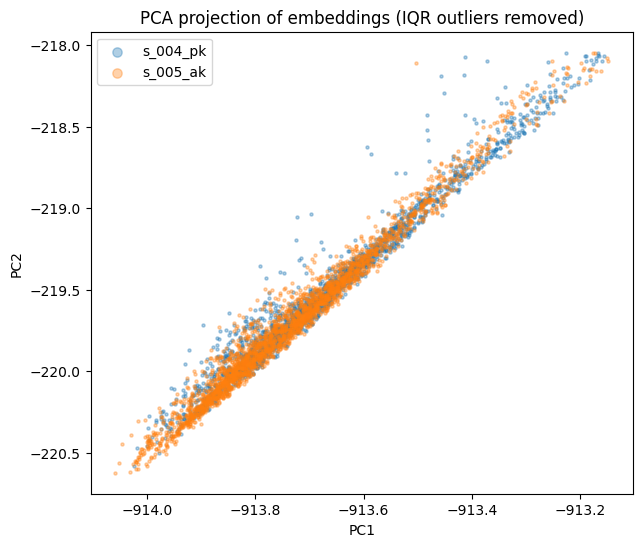


PCA plot (outliers removed) colored by 'sleep_feedback':


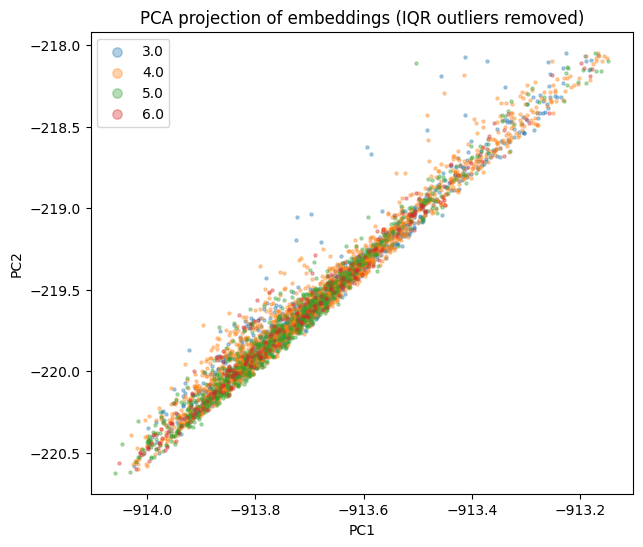

In [63]:
RANDOM_SUBSET_SIZE = 5000
if len(X) > RANDOM_SUBSET_SIZE:
    subset_idxs = np.random.choice(len(X), size=RANDOM_SUBSET_SIZE, replace=False)
    X_temp = X[subset_idxs]
    df_temp = df_heavy.iloc[subset_idxs].reset_index(drop=True)
    print(f"Using random subset of {RANDOM_SUBSET_SIZE} for PCA: {X.shape[0]} rows")

# Quick 2D projection with PCA implemented via NumPy SVD.
# Outliers are removed in PC space with an IQR rule before plotting.
X_centered = X_temp - X_temp.mean(axis=0, keepdims=True)
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
coords_2d = U[:, :2] * S[:2]
explained_ratio = (S ** 2) / np.sum(S ** 2)
print("Explained variance ratio (PC1, PC2):", explained_ratio[:2])

pc1 = coords_2d[:, 0]
pc2 = coords_2d[:, 1]

def iqr_bounds(x: np.ndarray, k: float = 1.5) -> tuple[float, float]:
    q1, q3 = np.quantile(x, [0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

l1, u1 = iqr_bounds(pc1, k=1.5)
l2, u2 = iqr_bounds(pc2, k=1.5)
inlier_mask = (pc1 >= l1) & (pc1 <= u1) & (pc2 >= l2) & (pc2 <= u2)

n_total = len(coords_2d)
n_inliers = int(inlier_mask.sum())
print(f"Inliers kept for PCA plot: {n_inliers:,} / {n_total:,} ({n_inliers / n_total:.1%})")

coords_plot = coords_2d[inlier_mask]
df_plot = df_temp.loc[inlier_mask].reset_index(drop=True)

observed_cols = ["subject", "sleep_feedback"]

for observed_col in observed_cols:
    print(f"\nPCA plot (outliers removed) colored by '{observed_col}':")
    fig, ax = plt.subplots(figsize=(7, 6))
    if observed_col in df_plot.columns:
        for label, g in df_plot.groupby(observed_col):
            idxs = g.index.to_numpy()
            ax.scatter(coords_plot[idxs, 0], coords_plot[idxs, 1], s=5, alpha=0.35, label=label)
        ax.legend(markerscale=3)
    else:
        ax.scatter(coords_plot[:, 0], coords_plot[:, 1], s=5, alpha=0.35)
    ax.set_title("PCA projection of embeddings (IQR outliers removed)")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    plt.show()


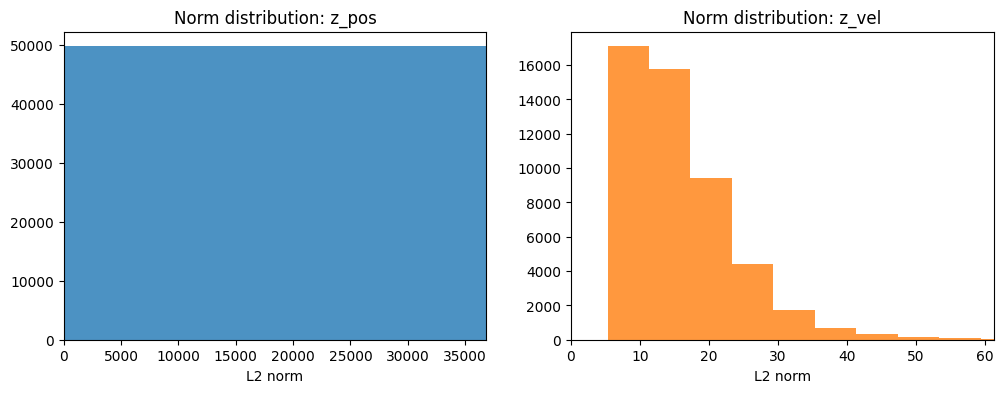

z_pos norm mean/std: 1398.46 37246.52
z_vel norm mean/std: 16.36 10.27


In [65]:
# Compare pos vs vel embedding norms.
pos_norm = np.linalg.norm(df_heavy[z_pos_cols].to_numpy(dtype=np.float32), axis=1)
vel_norm = np.linalg.norm(df_heavy[z_vel_cols].to_numpy(dtype=np.float32), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pos_norm, bins=60, alpha=0.8, color="tab:blue")
axes[0].set_title("Norm distribution: z_pos")
axes[1].hist(vel_norm, bins=60, alpha=0.8, color="tab:orange")
axes[1].set_title("Norm distribution: z_vel")
axes[0].set_xlabel("L2 norm")
axes[1].set_xlabel("L2 norm")
axes[0].set_xlim(0, np.percentile(pos_norm, 99.5))
axes[1].set_xlim(0, np.percentile(vel_norm, 99.5))
plt.show()

print("z_pos norm mean/std:", round(float(pos_norm.mean()), 2), round(float(pos_norm.std()), 2))
print("z_vel norm mean/std:", round(float(vel_norm.mean()), 2), round(float(vel_norm.std()), 2))


## Notes

- If `data/gazemae_outputs/` changes, update `EMBEDDINGS_PATH` and `SUMMARY_PATH` in the setup cell.
- For larger datasets, lower `MAX_ROWS_FOR_HEAVY` for faster exploratory runs.
